In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/digital_burnout_productivity_dataset_5M (1).csv")

In [ ]:
df.head()

,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,...,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,...,3,4,8.0,10,4,8,Balanced,46,100,High
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,...,7,6,5.0,7,9,7,Balanced,57,96,High
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,...,9,6,8.0,5,2,6,Balanced,29,79,High
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,...,10,5,6.0,4,5,3,Burnout,57,63,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,...,1,1,4.0,7,9,7,Focused,64,89,High


In [ ]:
df.shape

(5000000, 34)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 34 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int64  
 1   age                      int64  
 2   occupation               object 
 3   work_mode                object 
 4   device_usage_type        object 
 5   daily_screen_time        float64
 6   social_media_hours       float64
 7   doomscrolling_duration   float64
 8   app_switch_frequency     int64  
 9   notification_count       int64  
 10  smartphone_unlocks       int64  
 11  late_night_device_usage  int64  
 12  focus_sessions           int64  
 13  deep_work_hours          float64
 14  distraction_frequency    int64  
 15  task_completion_rate     int64  
 16  concentration_score      int64  
 17  sleep_hours              float64
 18  sleep_quality            int64  
 19  caffeine_intake          int64  
 20  physical_activity        float64
 21  stress_l

🌈 Dataset Features Overview

📱 Digital Behavior & Screen Usage


⏱️ Screen time tracking

🌐 App & device usage patterns

🔄 Frequency of checking devices

🌍 Social Media Activity


📲 Platform engagement levels

⚠️ Doomscrolling behavior

⏳ Time spent on feeds & content consumption


🎯 Focus & Deep Work Habits


🧠 Focus session duration

🚫 Distraction frequency

🔕 Deep work consistency

✅ Productivity & Task Performance


📋 Task completion rates

⚡ Work efficiency metrics

🎯 Concentration levels

💤 Health & Wellbeing Indicators

😴 Sleep quality & duration

🏃 Physical activity levels

😰 Stress indicators


🏠 Workplace Environment


🧑‍💻 Remote vs in-office behavior

🔇 Work interruptions

🪑 Work setup & environment stability


🧠 Psychological Factors


💪 Motivation levels

😵 Emotional exhaustion

🧩 Mental fatigue


🎯 Target Variables


🔥 burnout_risk → Predicts likelihood of burnout

📊 productivity_score → Continuous productivity measurement

🏷️ productivity_category → Classification label (e.g., Low / Medium / High)


🤖 Machine Learning Use

✨ This dataset supports:

📈 Regression → Predict productivity & burnout scores

🏷️ Classification → Categorize productivity levels

🧠 Behavioral analysis → Understand factors impacting performance

In [ ]:
df.describe()

,user_id,age,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,...,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,burnout_risk,productivity_score
count,5.000000e+06,5.000000e+06,5.000000e+06,4.900000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,...,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,4.900000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,2.500000e+06,3.849935e+01,8.001010e+00,3.517651e+00,1.834645e+00,1.294981e+02,2.094380e+02,1.570431e+02,6.499932e-01,4.500512e+00,...,5.498445e+00,2.529647e+00,5.500410e+00,3.000608e+00,5.499446e+00,5.499560e+00,5.502012e+00,5.500900e+00,4.858374e+01,7.144397e+01
std,1.443376e+06,1.212046e+01,2.494805e+00,1.759434e+00,1.132208e+00,6.928145e+01,1.096646e+02,8.228162e+01,4.769718e-01,2.872723e+00,...,2.871775e+00,1.437845e+00,2.873046e+00,1.999887e+00,2.871916e+00,2.872018e+00,2.871822e+00,2.872481e+00,2.207203e+01,2.149899e+01
min,1.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01,2.000000e+01,1.500000e+01,0.000000e+00,0.000000e+00,...,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.250001e+06,2.800000e+01,6.300000e+00,2.300000e+00,1.000000e+00,6.900000e+01,1.140000e+02,8.600000e+01,0.000000e+00,2.000000e+00,...,3.000000e+00,1.500000e+00,3.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.300000e+01,5.600000e+01
50%,2.500000e+06,3.800000e+01,8.000000e+00,3.500000e+00,1.800000e+00,1.290000e+02,2.090000e+02,1.570000e+02,1.000000e+00,5.000000e+00,...,5.000000e+00,2.500000e+00,6.000000e+00,3.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00,6.000000e+00,4.800000e+01,7.300000e+01
75%,3.750000e+06,4.900000e+01,9.700000e+00,4.700000e+00,2.600000e+00,1.900000e+02,3.040000e+02,2.280000e+02,1.000000e+00,7.000000e+00,...,8.000000e+00,3.500000e+00,8.000000e+00,5.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,6.400000e+01,9.000000e+01
max,5.000000e+06,5.900000e+01,1.800000e+01,1.200000e+01,7.900000e+00,2.490000e+02,3.990000e+02,2.990000e+02,1.000000e+00,9.000000e+00,...,1.000000e+01,1.000000e+01,1.000000e+01,6.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+02,1.000000e+02


In [ ]:
((df.isnull().sum()/df.shape[0])*100).round(2)

,0
user_id,0.0
age,0.0
occupation,0.0
work_mode,0.0
device_usage_type,0.0
daily_screen_time,0.0
social_media_hours,2.0
doomscrolling_duration,0.0
app_switch_frequency,0.0
notification_count,0.0


In [ ]:
percent_missing = ((df.isnull().sum()/df.shape[0])*100).round(2)

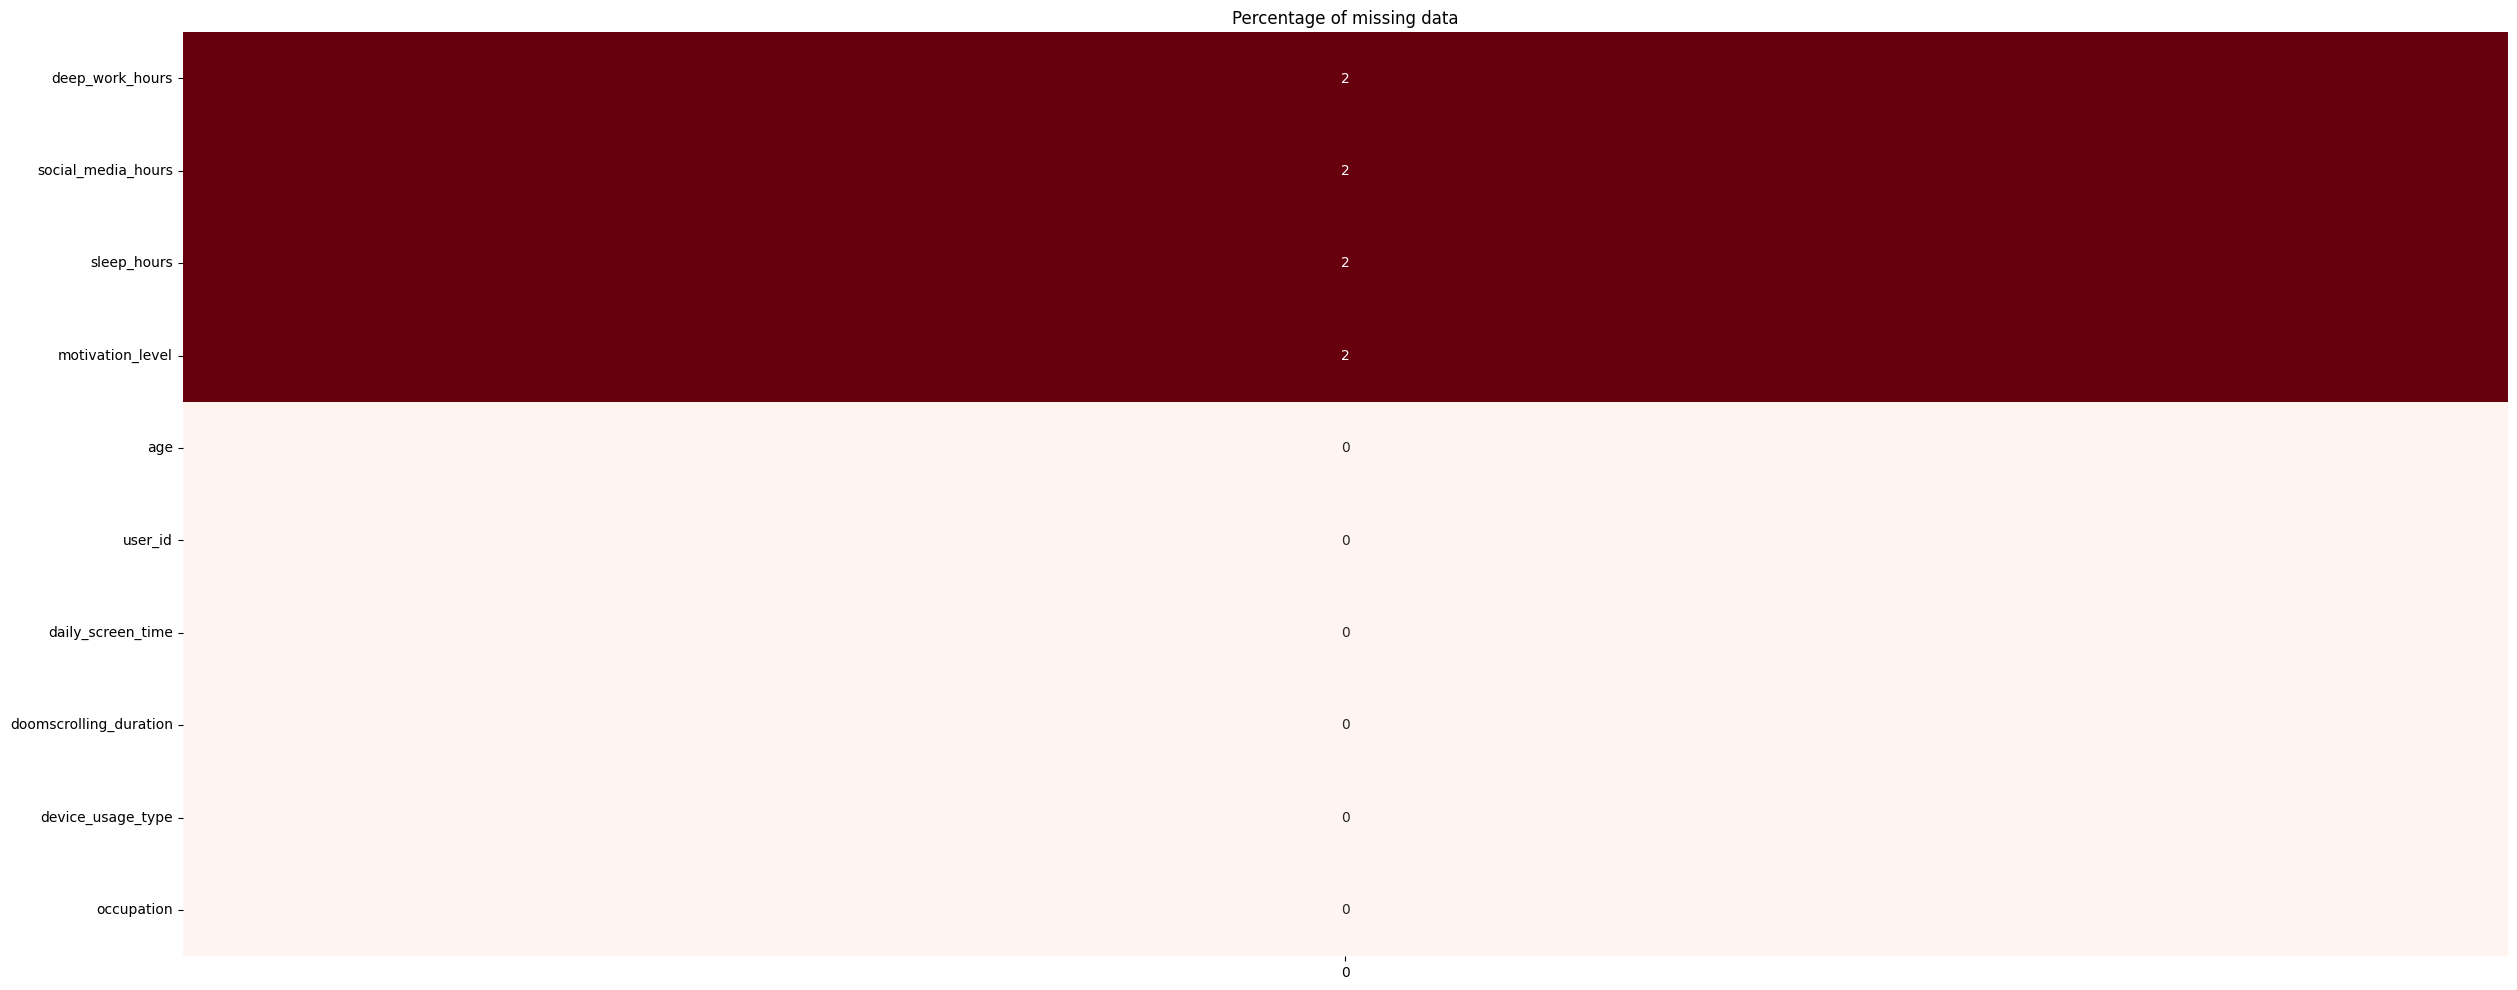

In [ ]:
plt.figure(figsize = (30,12))
sns.heatmap(percent_missing.sort_values(ascending=False).to_frame().head(10), annot= True, cmap = "Reds" ,cbar = False)
plt.title("Percentage of missing data")
plt.show()

# **The proportion of missing data is below 3%; therefore, mean imputation will be applied.**

In [ ]:
missing_data_columns = list(percent_missing[percent_missing>0].index)
missing_data_columns

['social_media_hours', 'deep_work_hours', 'sleep_hours', 'motivation_level']

In [ ]:
for col in missing_data_columns:
  df[col].fillna(df[col].mean(), inplace = True)

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
occupation,0
work_mode,0
device_usage_type,0
daily_screen_time,0
social_media_hours,0
doomscrolling_duration,0
app_switch_frequency,0
notification_count,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# **There are no duplicated data**

In [ ]:
numerical_features = [ feature for feature in df.columns if df[feature].dtype != "object"]
print(f' We have {len(numerical_features)} numerical features and these are the list: \n{numerical_features}')

 We have 29 numerical features and these are the list: 
['user_id', 'age', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'app_switch_frequency', 'notification_count', 'smartphone_unlocks', 'late_night_device_usage', 'focus_sessions', 'deep_work_hours', 'distraction_frequency', 'task_completion_rate', 'concentration_score', 'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity', 'stress_level', 'workspace_quality', 'meeting_hours', 'internet_stability', 'remote_work_days', 'motivation_level', 'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction', 'burnout_risk', 'productivity_score']


In [ ]:
categorical_features = [ feature for feature in df.columns if df[feature].dtype == "object"]
categorical_features
print(f' We have {len(categorical_features)} categorical features and these are the list: \n{categorical_features}')

 We have 5 categorical features and these are the list: 
['occupation', 'work_mode', 'device_usage_type', 'mental_state', 'productivity_category']


In [ ]:
cat_data ={}
cat_data_list ={}

for col in categorical_features:
  cat_data[col] = len(df[col].unique())
  cat_data_list[col] = df[col].unique()

In [ ]:
print(f"The following categorical columns contain these number of unique values:\n{cat_data}")
print(f"The following categorical columns contain these unique values:\n{cat_data_list}\n")

The following categorical columns contain these number of unique values:
{'occupation': 7, 'work_mode': 3, 'device_usage_type': 3, 'mental_state': 4, 'productivity_category': 3}
The following categorical columns contain these unique values:
{'occupation': array(['Content Creator', 'Student', 'Software Engineer', 'Designer',
       'Analyst', 'Freelancer', 'Manager'], dtype=object), 'work_mode': array(['Office', 'Hybrid', 'Remote'], dtype=object), 'device_usage_type': array(['Entertainment-Centric', 'Work-Centric', 'Balanced'], dtype=object), 'mental_state': array(['Balanced', 'Burnout', 'Focused', 'Distracted'], dtype=object), 'productivity_category': array(['High', 'Medium', 'Low'], dtype=object)}



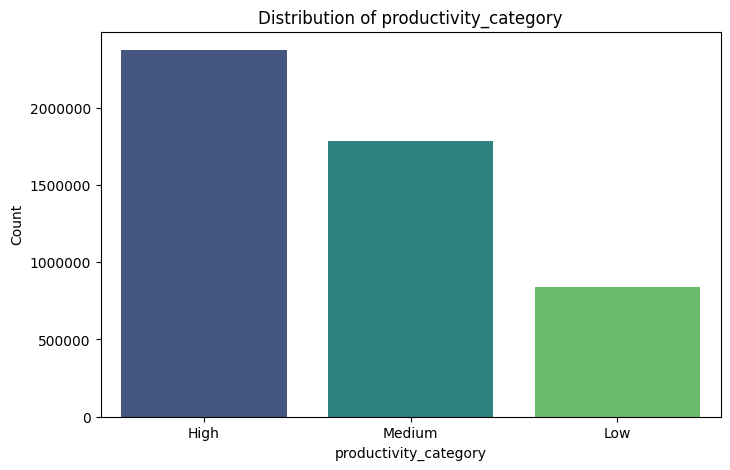

In [ ]:
# Plot target distribution
plt.figure(figsize=(8,5))
sns.countplot(x='productivity_category', data=df, palette='viridis')
plt.title('Distribution of productivity_category')
plt.xlabel('productivity_category')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis= 'y')
plt.show()

In [ ]:
df['productivity_score'].skew()

np.float64(-0.4543344760748216)

<Axes: >

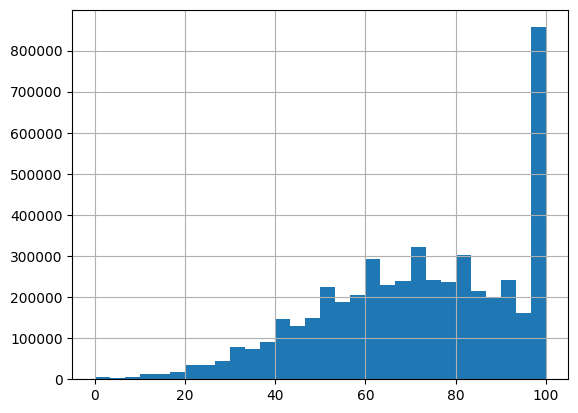

In [ ]:
df['productivity_score'].hist(bins = 30)

In [ ]:
df.groupby('productivity_category')['productivity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
productivity_category,,,,,,,,
High,2374159.0,90.088842,8.762336,75.0,82.0,91.0,100.0,100.0
Low,841484.0,37.054214,10.208695,0.0,31.0,40.0,45.0,49.0
Medium,1784357.0,62.854054,7.057299,50.0,57.0,63.0,69.0,74.0


# **The target is imbalanced across the three classes, High has the largest number of samples, Medium has a moderate number of samples and Low has the fewest samples**

In [ ]:
for col in categorical_features:
  print(f'{df.groupby(col)['productivity_score'].mean().sort_values}')
  print()

<bound method Series.sort_values of occupation
Analyst              71.424493
Content Creator      71.432281
Designer             71.459816
Freelancer           71.464760
Manager              71.429984
Software Engineer    71.439077
Student              71.457359
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of work_mode
Hybrid    71.458965
Office    71.437565
Remote    71.435166
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of device_usage_type
Balanced                 71.429731
Entertainment-Centric    71.453416
Work-Centric             71.450101
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of mental_state
Balanced      71.633843
Burnout       66.518782
Distracted    71.632977
Focused       74.965598
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of productivity_category
High      90.088842
Low       37.054214
Medium    62.854054
Name: productivity_score, dtype: flo

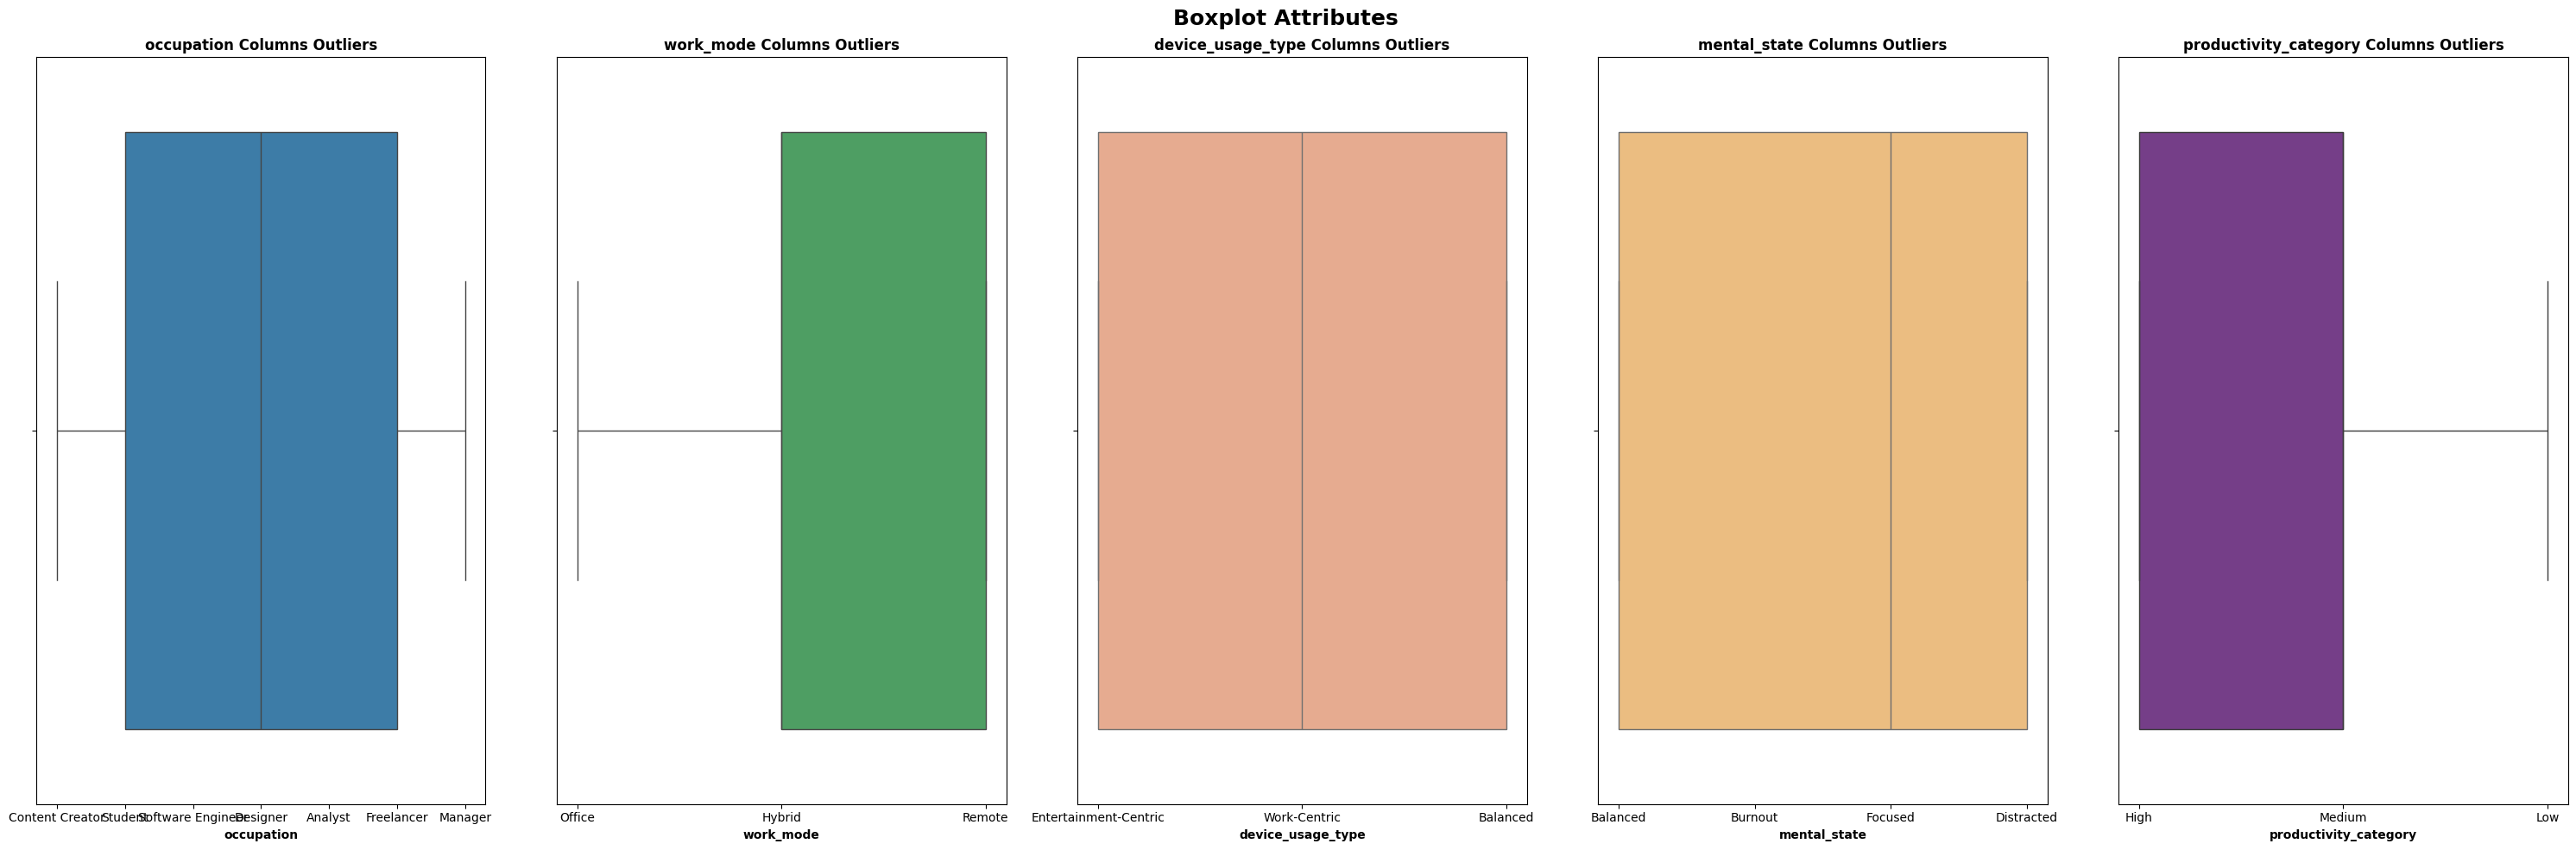

In [ ]:
fig, axes = plt.subplots(1,5, figsize = (30,10))
colours = ['#2C7FB8', '#41AB5D', '#F4A582', '#FDBF6F', '#7B3294']
axes = axes.flatten()
# plt.delaxes(axes[-1])
for i in range(len(categorical_features)):
  sns.boxplot(x = df[categorical_features[i]], ax = axes[i], color = colours[i])
  axes[i].set_xlabel(f'{categorical_features[i]}', fontweight= 'bold')
  axes[i].set_title(f'{categorical_features[i]} Columns Outliers', fontweight = 'bold')

plt.suptitle("Boxplot Attributes" , fontweight = 'bold', fontsize = 18)
plt.tight_layout()
plt.show()

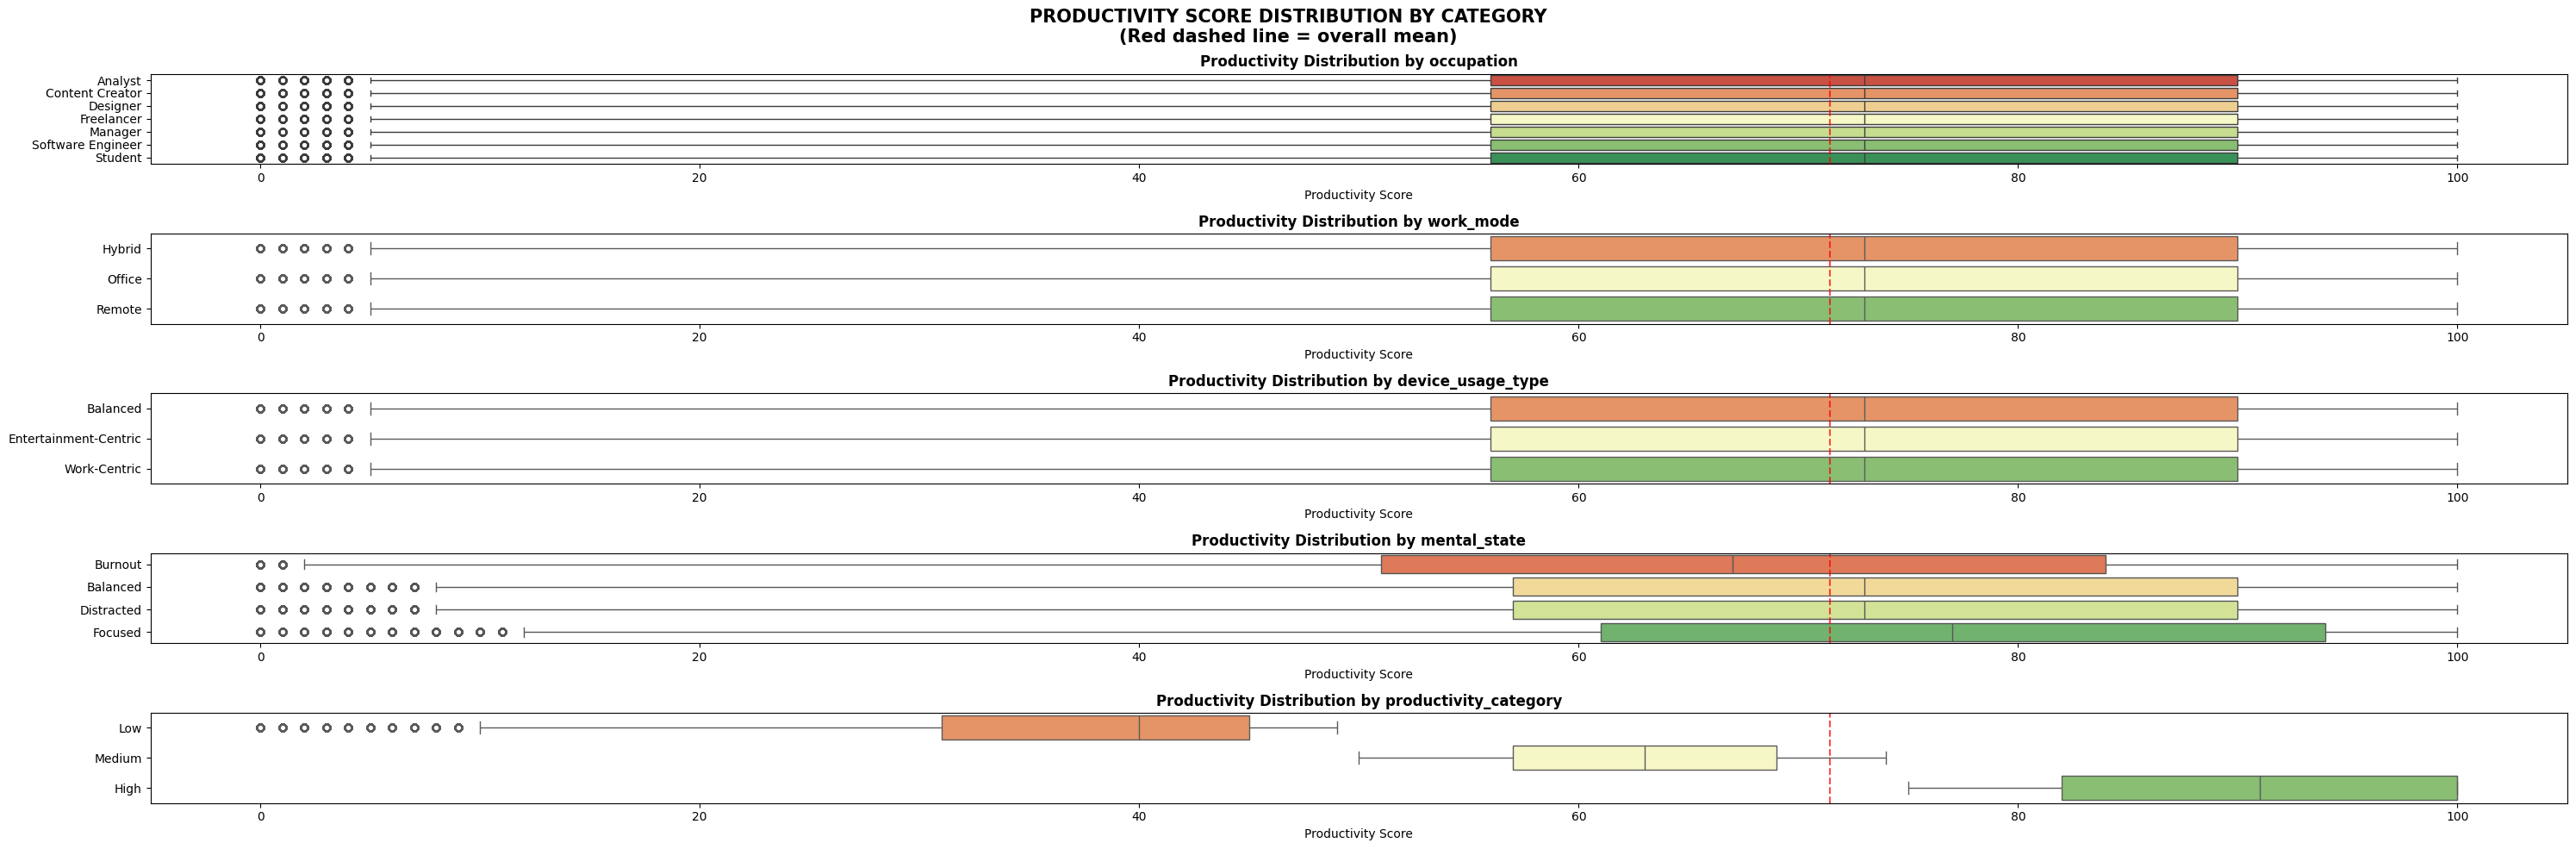

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(30, 10))

axes = axes.flatten()

for i, col in enumerate(categorical_features):

    order = (df.groupby(col)['productivity_score']

             .median()

             .sort_values()

             .index)

    sns.boxplot(

        data=df,

        x='productivity_score',

        y=col,

        order=order,

        palette='RdYlGn',

        ax=axes[i]

    )

    axes[i].axvline(df['productivity_score'].mean(), color='red', ls='--', lw=1.5, alpha=0.7)
    axes[i].set_title(f'Productivity Distribution by {col}', fontweight='bold')
    axes[i].set_xlabel('Productivity Score')
    axes[i].set_ylabel('')
plt.suptitle('PRODUCTIVITY SCORE DISTRIBUTION BY CATEGORY\n'          '(Red dashed line = overall mean)',

             fontsize=15, fontweight='bold')

plt.tight_layout()

plt.show()


# **Productivity scores are predominantly concentrated in the mid-to-high range, with mental state emerging as the most significant differentiator, while occupation and device usage show moderate effects and work mode exhibits minimal impact; the predefined productivity categories are well-separated and consistent with the underlying score distribution.**

# **Feature Group Analysis**

Screen behavior (the “digital habits” cluster):
• daily_screen_time, social_media_hours, doomscrolling_duration, app_switch_frequency, notification_count, smartphone_unlocks, late_night_device_usage

Focus and work quality cluster:
• focus_sessions, deep_work_hours, distraction_frequency, task_completion_rate, concentration_score


Health and wellbeing cluster:
• sleep_hours, sleep_quality, caffeine_intake, physical_activity, stress_level, mental_fatigue, emotional_exhaustion

Work environment cluster:
• workspace_quality, meeting_hours, internet_stability, remote_work_days, work_satisfaction, motivation_level

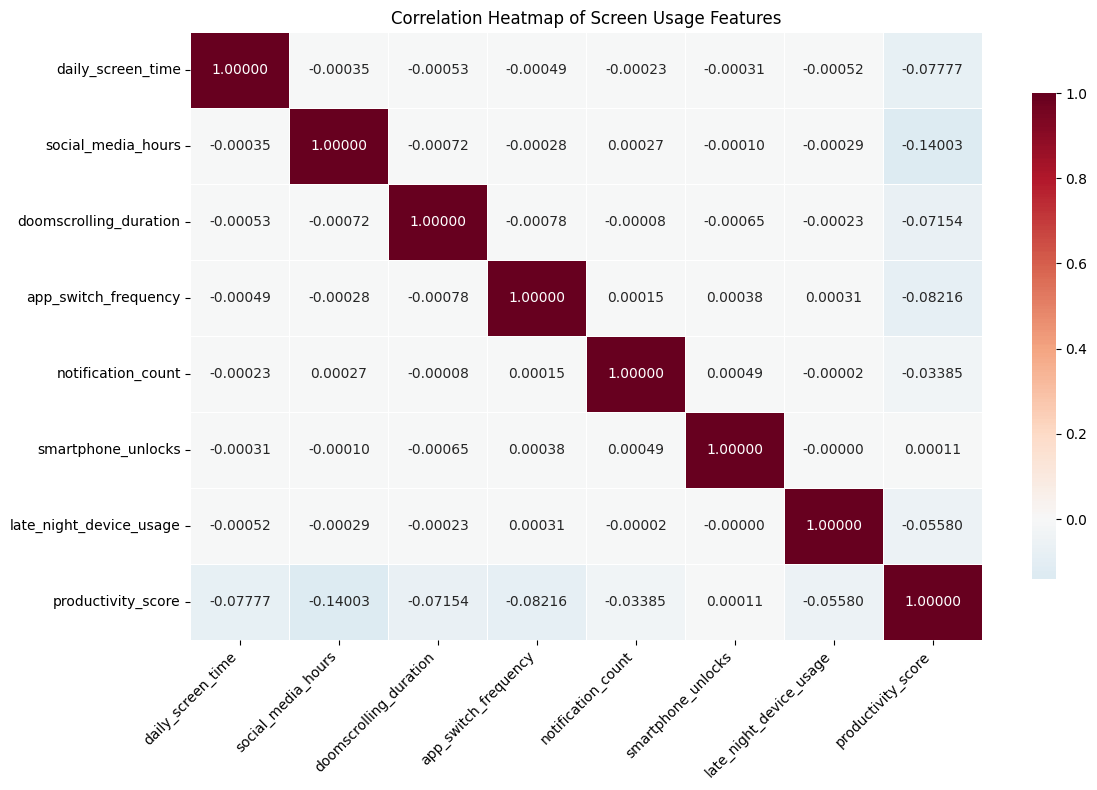

In [ ]:
Screen_behavior_cols = ['daily_screen_time', 'social_media_hours',
              'doomscrolling_duration', 'app_switch_frequency',
              'notification_count', 'smartphone_unlocks',
              'late_night_device_usage', 'productivity_score']
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Screen_behavior_cols].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Screen Usage Features", fontsize=12)

plt.tight_layout()
plt.show()


The heatmap shows that screen usage features have extremely weak linear relationships with productivity, indicating that any influence they have is likely nonlinear or minimal.

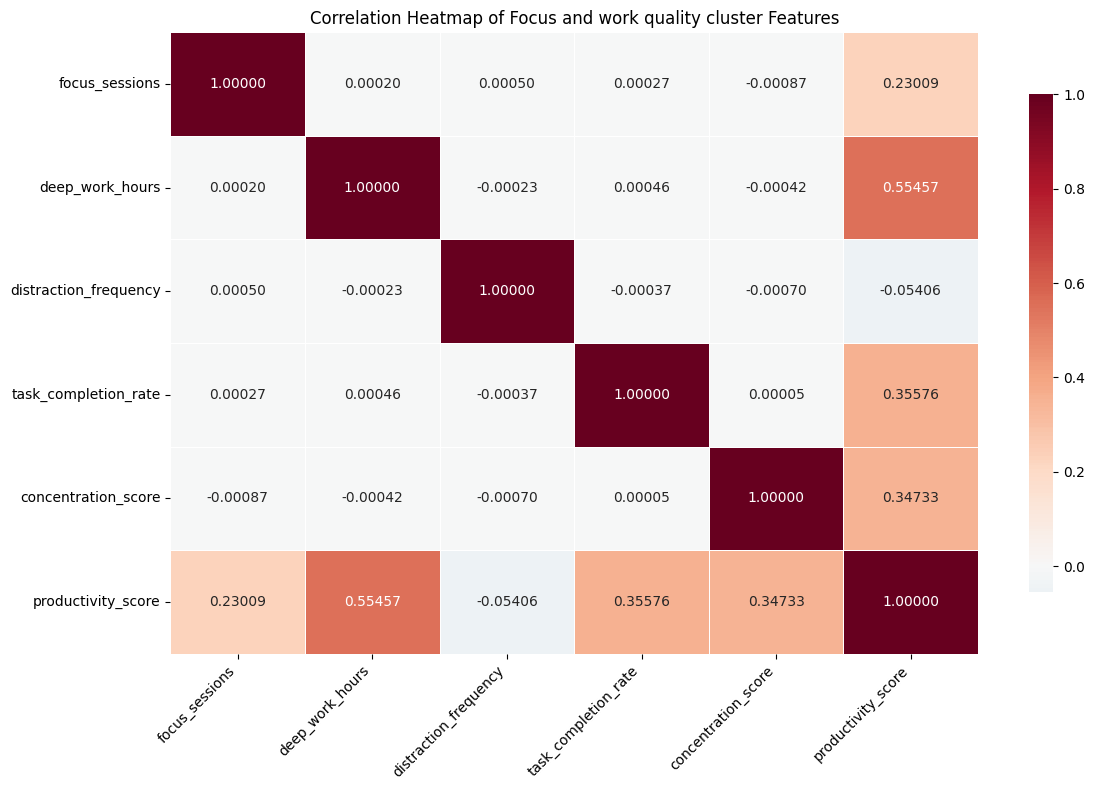

In [ ]:
Focus_and_work_quality_cluster = [ "focus_sessions", "deep_work_hours", "distraction_frequency", "task_completion_rate", "concentration_score", 'productivity_score']

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Focus_and_work_quality_cluster].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Focus and work quality cluster Features", fontsize=12)

plt.tight_layout()
plt.show()

**Unlike screen usage features, focus and work-quality variables show strong and meaningful relationships with productivity, with deep work hours emerging as the most important driver.**

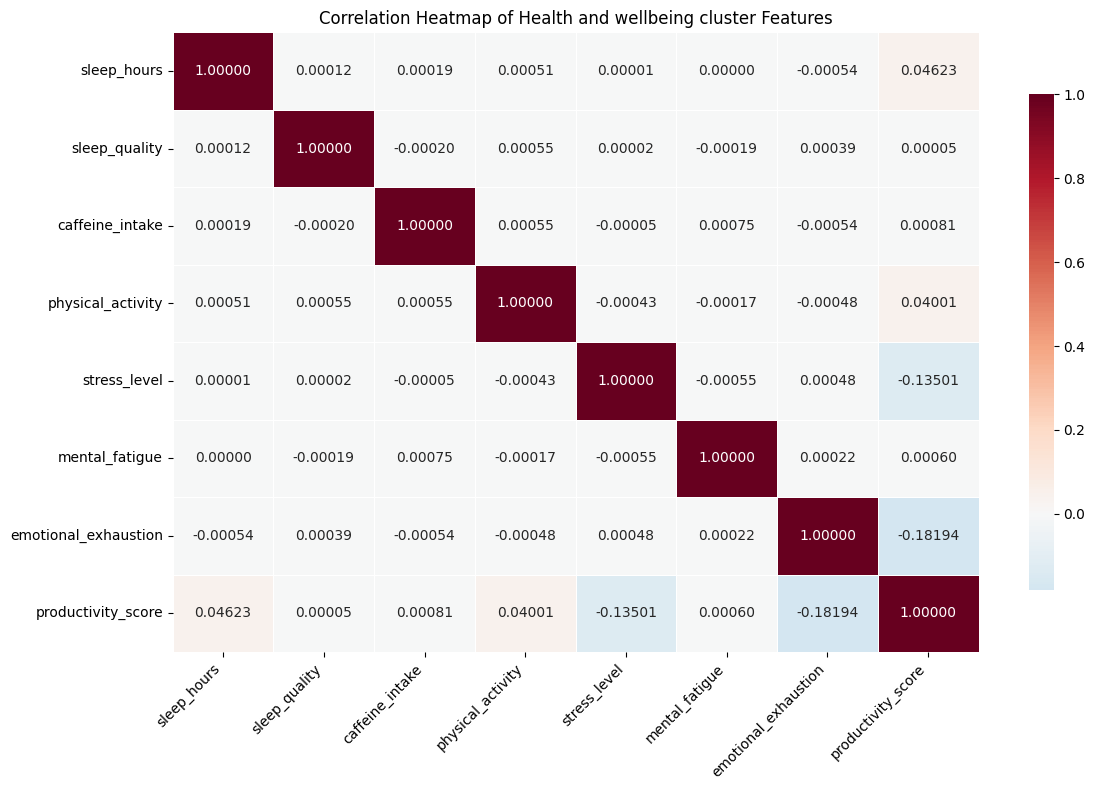

In [ ]:
Health_and_wellbeing_cluster = ["sleep_hours", "sleep_quality", "caffeine_intake", "physical_activity", "stress_level", "mental_fatigue", "emotional_exhaustion", "productivity_score" ]
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Health_and_wellbeing_cluster].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Health and wellbeing cluster Features", fontsize=12)

plt.tight_layout()
plt.show()

**Productivity is not strongly driven by lifestyle metrics directly, but by the ability to focus and work deeply, which is influenced (to some extent) by stress and emotional exhaustion.**

**Health and wellbeing variables show weak direct correlations with productivity, with emotional exhaustion and stress level being the only meaningful negative drivers, while most other factors (sleep, caffeine, activity) exhibit minimal direct influence.**

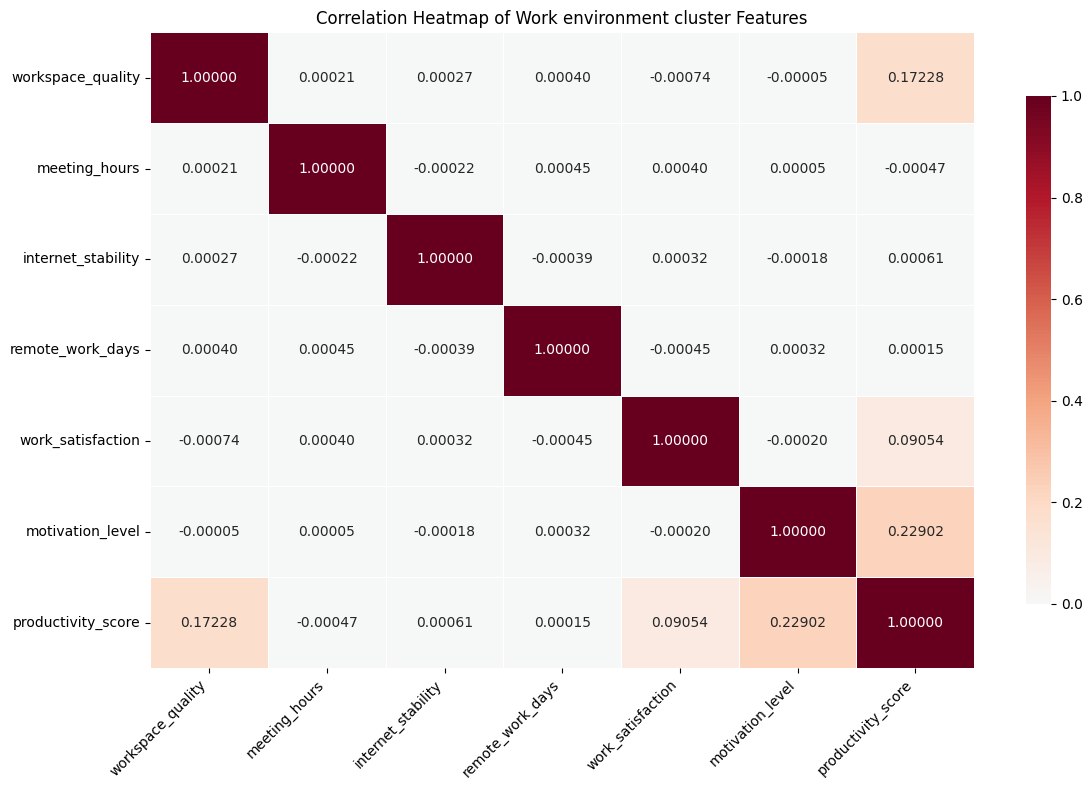

In [ ]:
Work_environment_cluster = ["workspace_quality", "meeting_hours", "internet_stability", "remote_work_days", "work_satisfaction", "motivation_level", "productivity_score"]
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Work_environment_cluster].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Work environment cluster Features", fontsize=12)

plt.tight_layout()
plt.show()

**Productivity depends more on internal mindset and working style than external environment.**

**Work environment has some influence on productivity (mainly through motivation and workspace quality), but its impact is significantly weaker than focus and deep work behaviours.**

**Among work environment features, motivation level and workspace quality show moderate influence on productivity, while factors like meetings, internet stability, and remote work have negligible impact.**



burnout_risk              -0.377971
emotional_exhaustion      -0.181940
social_media_hours        -0.140029
stress_level              -0.135014
app_switch_frequency      -0.082157
daily_screen_time         -0.077772
doomscrolling_duration    -0.071542
late_night_device_usage   -0.055803
distraction_frequency     -0.054059
notification_count        -0.033855
age                       -0.001348
meeting_hours             -0.000468
sleep_quality              0.000047
smartphone_unlocks         0.000110
remote_work_days           0.000153
mental_fatigue             0.000603
internet_stability         0.000613
caffeine_intake            0.000810
physical_activity          0.040005
sleep_hours                0.046233
work_satisfaction          0.090537
workspace_quality          0.172281
motivation_level           0.229024
focus_sessions             0.230093
concentration_score        0.347326
task_completion_rate       0.355764
deep_work_hours            0.554574
Name: productivity_score, dt

<Axes: >

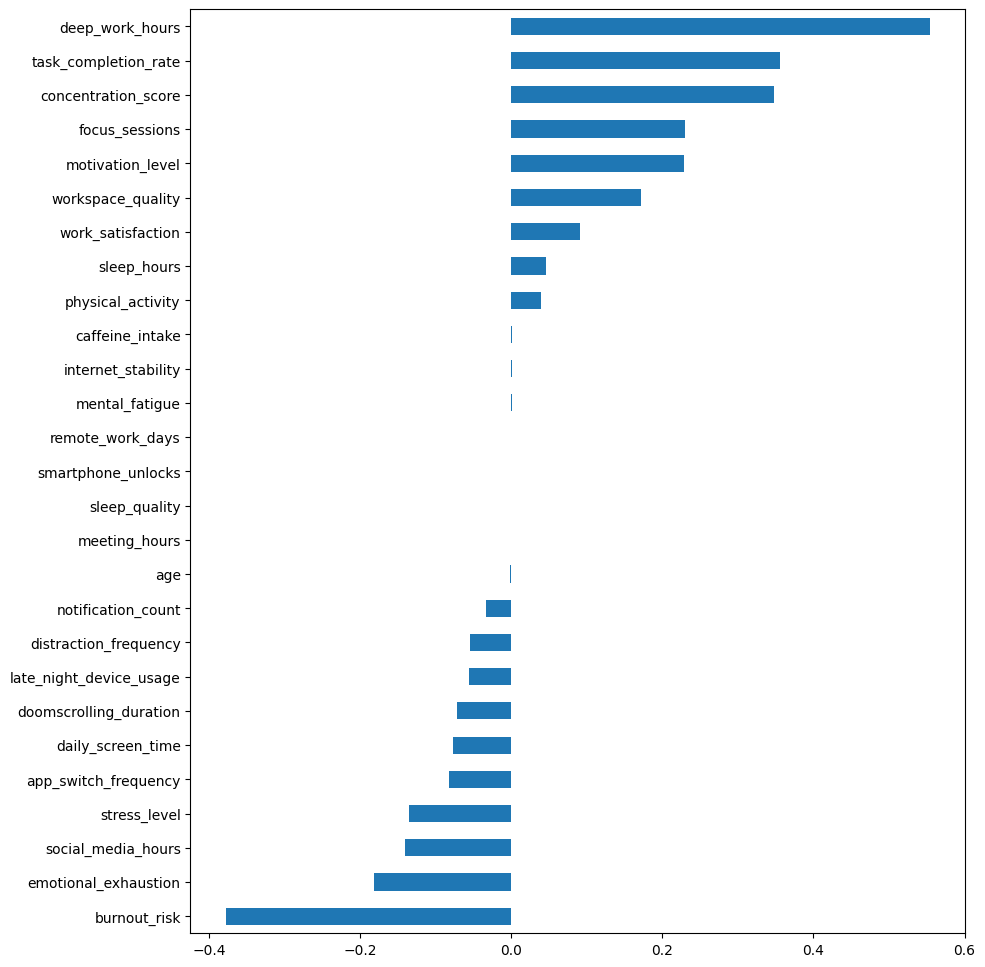

In [ ]:
corr = df.select_dtypes(include='number').corr()['productivity_score']
corr = corr.drop(['productivity_score', 'user_id']).sort_values()
print(corr)
corr.plot.barh(figsize=(10, 12))

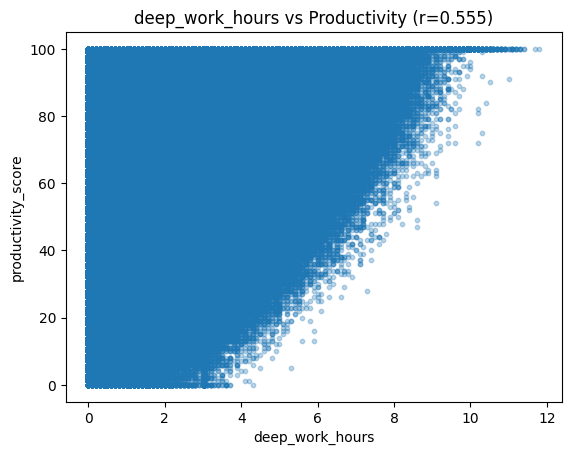

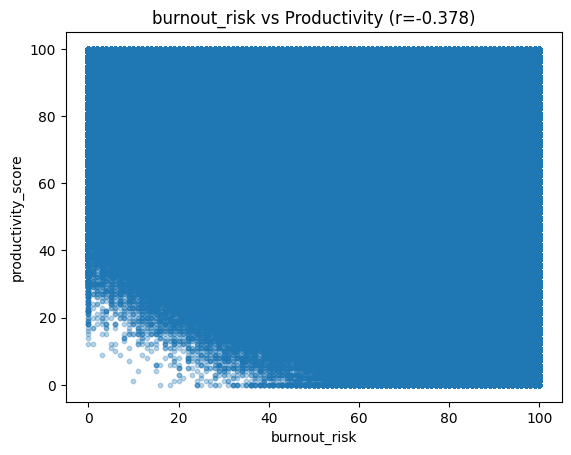

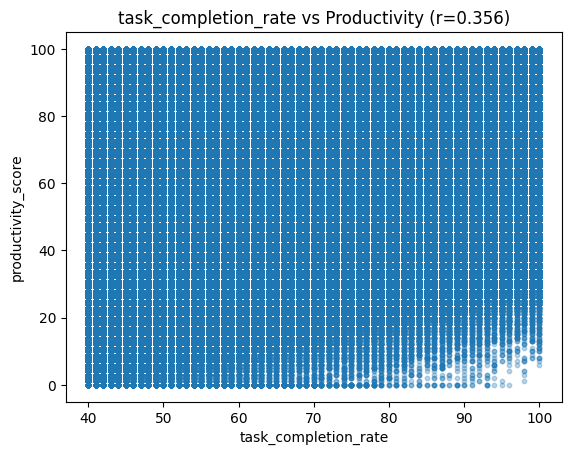

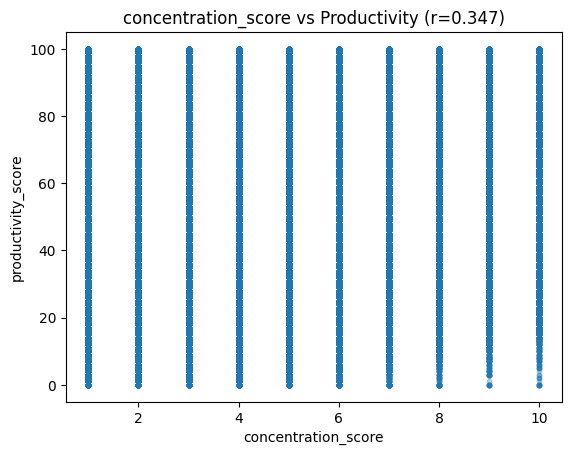

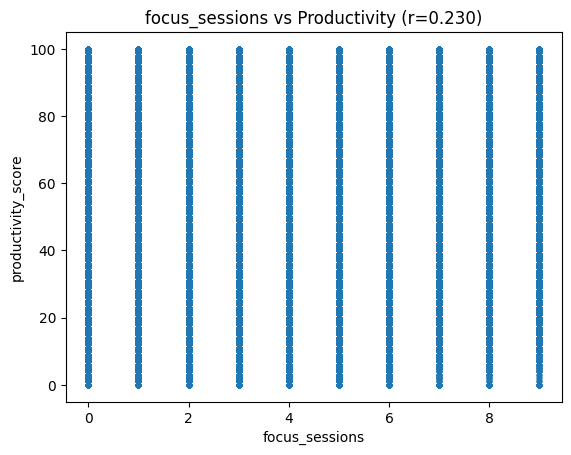

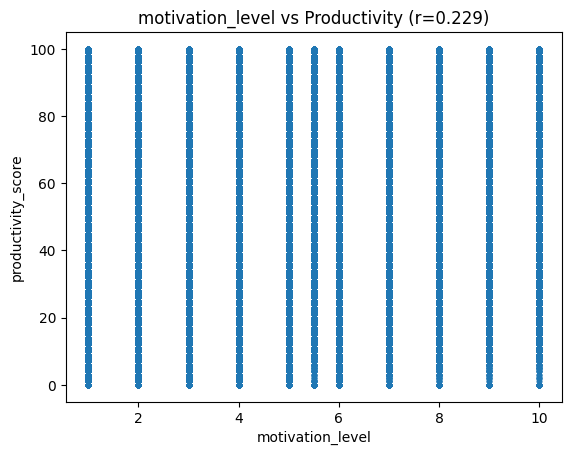

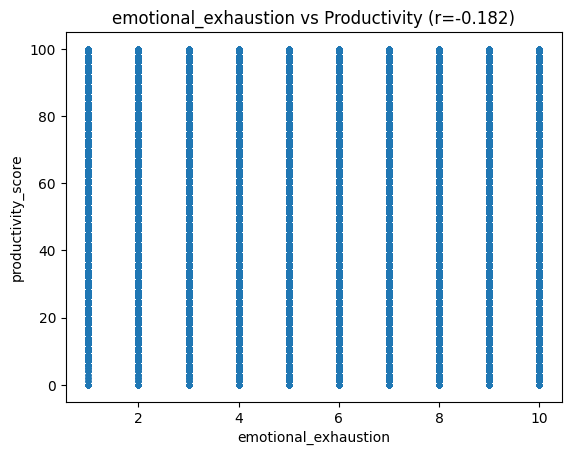

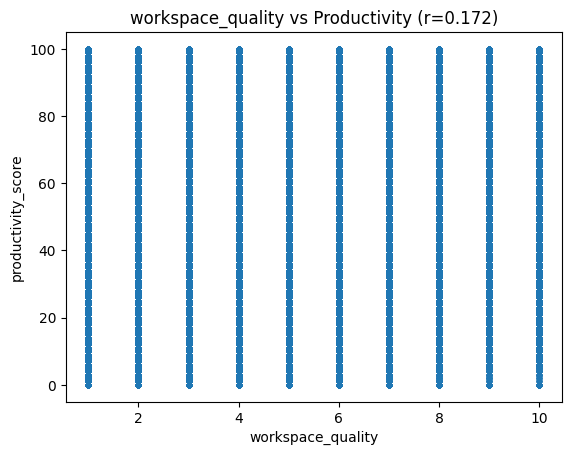

In [ ]:
top_features = corr.abs().sort_values(ascending=False).head(8).index
for feat in top_features:
   plt.scatter(df[feat], df['productivity_score'], alpha=0.3, s=10)
   plt.xlabel(feat)
   plt.ylabel('productivity_score')
   plt.title(f'{feat} vs Productivity (r={df[feat].corr(df["productivity_score"]):.3f})')
   plt.show()

In [ ]:
df['sleep_group'] = pd.qcut(df['sleep_hours'], 3, labels=['Low','Mid','High'])
for group in df['sleep_group'].unique():
   subset = df[df['sleep_group'] == group]
   corr = subset['doomscrolling_duration'].corr(subset['productivity_score'])
   print(f"Sleep={group}: doomscrolling-productivity correlation = {corr:.3f}")


for mode in df['work_mode'].unique():
   subset = df[df['work_mode'] == mode]
   corr = subset['deep_work_hours'].corr(subset['productivity_score'])
   print(f"{mode}: deep_work-productivity correlation = {corr:.3f}")


Sleep=Low: doomscrolling-productivity correlation = -0.072
Sleep=Mid: doomscrolling-productivity correlation = -0.071
Sleep=High: doomscrolling-productivity correlation = -0.072
Office: deep_work-productivity correlation = 0.555
Hybrid: deep_work-productivity correlation = 0.555
Remote: deep_work-productivity correlation = 0.554


# **Deep work has a strong and consistent positive relationship with productivity across all work modes, making it a reliable and robust predictor. and Doomscrolling shows a weak and stable negative relationship with productivity, indicating minimal influence regardless of sleep level.**



In [ ]:
sleep_bins = pd.qcut(df['sleep_quality'], 3, labels=['Low','Mid','High'])

for mode in sleep_bins.unique():
    subset = df[sleep_bins == mode]
    corr = subset['deep_work_hours'].corr(subset['productivity_score'])
    print(f"{mode} quality of sleep productivity correlation: = {corr:.3f}")


High quality of sleep productivity correlation: = 0.554
Mid quality of sleep productivity correlation: = 0.555
Low quality of sleep productivity correlation: = 0.554


In [ ]:
full_corr = df.select_dtypes(include='number').drop(columns=['user_id']).corr()
high_corr_pairs = []
for i in range(len(full_corr.columns)):
   for j in range(i+1, len(full_corr.columns)):
       if abs(full_corr.iloc[i, j]) > 0.8:
           high_corr_pairs.append((
               full_corr.columns[i],
               full_corr.columns[j],
               full_corr.iloc[i, j]
           ))
for f1, f2, r in high_corr_pairs:
   print(f"{f1} ↔ {f2}: {r:.3f}")

We do not have any high correlation features, hence we are not dropping any redundant column

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.drop(['user_id'])
for col in numeric_cols:
   q1 = df[col].quantile(0.25)
   q3 = df[col].quantile(0.75)
   iqr = q3 - q1
   outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
   if outliers > 0:
       pct = outliers / len(df) * 100
       print(f"{col}: {outliers} outliers ({pct:.1f}%)")

daily_screen_time: 34754 outliers (0.7%)
social_media_hours: 17325 outliers (0.3%)
doomscrolling_duration: 16924 outliers (0.3%)
deep_work_hours: 17362 outliers (0.3%)
physical_activity: 15999 outliers (0.3%)
meeting_hours: 17087 outliers (0.3%)
productivity_score: 7707 outliers (0.2%)


# **The dataset has outliers, but they are minimal and not a major problem**

In [ ]:
burnout_corrs = df[['burnout_risk', 'stress_level', 'mental_fatigue',
                    'emotional_exhaustion', 'sleep_quality',
                    'work_satisfaction']].corr()['burnout_risk']
print(burnout_corrs)

burnout_risk            1.000000
stress_level            0.382824
mental_fatigue         -0.000124
emotional_exhaustion    0.511981
sleep_quality          -0.000035
work_satisfaction      -0.254354
Name: burnout_risk, dtype: float64


In [ ]:
df_original = df.copy()

# **Feature Engineer**

DIGITAL DISTRACTION BURDEN - How much the device is pulling employee's attention

In [ ]:
#To calculate the total number of times the brain was interrupted
df['total_distraction_exposure'] = (df['notification_count'] + df['app_switch_frequency'] + df['smartphone_unlocks'])
total_distraction_exposure_corr = df['total_distraction_exposure'].corr(df['productivity_score'])
print(total_distraction_exposure_corr.round(3))


-0.061


The total distraction exposure shows a weak negative relationship with productivity, indicating that interruption frequency alone is not a strong driver of productivity compared to factors like deep work.

*Compulsive Phone Checking (Unlock Frequency)*

In [ ]:
df['phone_checking_compulsion'] = df['smartphone_unlocks'] / (df['daily_screen_time'] + 1)
phone_checking_compulsion_corr = df['phone_checking_compulsion'].corr(df['productivity_score'])
print(phone_checking_compulsion_corr.round(2))

0.04


The unlocking frequency also shows a weak negative relationship with productivity, indicating that unlocking frequency alone is not a strong driver of productivity compared to factors like deep work.

Social Media + Doomscroll Ratio

In [ ]:
df['social_media_engagement'] = (   (df['social_media_hours'] + df['doomscrolling_duration']) / (df['daily_screen_time'] + 1))
social_media_engagement_corr = df['social_media_engagement'].corr(df['productivity_score'])
print(social_media_engagement_corr.round(2))

-0.06


In [ ]:
df['notification_intensity'] = ( df['notification_count'] / (df['daily_screen_time'] + 1))
notification_intensity_corr = df['notification_intensity'].corr(df['productivity_score'])
print(notification_intensity_corr.round(2))

0.01


In [ ]:
df['app_switching_intensity'] = ( df['app_switch_frequency'] / (df['daily_screen_time'] + 1))
app_switching_intensity_corr = df['app_switching_intensity'].corr(df['productivity_score'])
print(app_switching_intensity_corr.round(2))

-0.02


In [ ]:
df['evening_screen_dependency'] = (df['late_night_device_usage'] / (df['daily_screen_time'] + 1))
evening_screen_dependency_corr = df['evening_screen_dependency'].corr(df['productivity_score'])
print(evening_screen_dependency_corr.round(2))

-0.02


In [ ]:
df['digital_wellness'] = ( (1 - df['social_media_engagement']) *   (1 - df['evening_screen_dependency']) *  (1 - df['phone_checking_compulsion']) )
digital_wellness_corr = df['digital_wellness'].corr(df['productivity_score'])
print(digital_wellness_corr.round(2))

-0.04


BIOLOGICAL READINESS

In [ ]:
df['sleep_deficit'] = np.maximum(0, 8 - df['sleep_hours'])
df['sleep_effectiveness'] = df['sleep_quality'] * df['sleep_hours']
df['caffeine_dependence'] = df['caffeine_intake'] / (df['sleep_quality'] + 1)
df['physical_recovery_capacity'] = df['physical_activity'] * df['sleep_quality']
df['daily_energy_balance'] = (
   df['sleep_quality'] + df['physical_activity'] - df['stress_level'] - (df['caffeine_intake'] / 10)
)
df['stress_resilience'] = df['physical_activity'] / (df['stress_level'] + 1)

PSYCHOLOGICAL READINESS

In [ ]:
df['emotional_stability'] = (
   (10 - df['mental_fatigue']) + (10 - df['emotional_exhaustion']) + df['motivation_level']
) / 3
df['burnout_trajectory'] = (
   df['burnout_risk'] *
   (1 + df['emotional_exhaustion'] / 100) *
   (1 + df['mental_fatigue'] / 100)
)
df['motivation_durability'] = df['motivation_level'] / (df['mental_fatigue'] + 1)
df['satisfaction_gap'] = np.abs(df['work_satisfaction'] - df['motivation_level'])
df['psychological_readiness'] = (
   df['motivation_level'] * 0.4 +
   df['work_satisfaction'] * 0.3 +
   (10 - df['stress_level']) * 0.2 +
   (10 - df['mental_fatigue']) * 0.1
)


WORK ENVIRONMENT FRICTION

In [ ]:
df['meeting_burden'] = df['meeting_hours'] / 8
df['actual_work_time'] = 8 - df['meeting_hours']
df['deep_work_efficiency'] = df['deep_work_hours'] / np.maximum(1, df['actual_work_time'])
df['distraction_burden_work'] = df['distraction_frequency'] / (df['focus_sessions'] + 1)
df['remote_work_sustainability'] = df['remote_work_days'] * (df['deep_work_hours'] / np.maximum(1, df['meeting_hours']))
df['digital_infrastructure_score'] = df['internet_stability'] * (1 + df['remote_work_days'] / 5)
df['work_environment_quality'] = df['workspace_quality'] * 0.6 + df['internet_stability'] * 0.4
df['productive_time_available'] = df['deep_work_hours'] + df['focus_sessions'] - df['distraction_frequency']

INTERACTION FEATURES

In [ ]:
df['distraction_sleep_interaction'] = df['social_media_engagement'] * (10 - df['sleep_quality'])
df['stress_management_effectiveness'] = (df['stress_level'] + 1) / (df['physical_activity'] + df['motivation_level'] + 1)
df['health_work_alignment'] = df['daily_energy_balance'] * df['work_environment_quality']
df['cognitive_overload'] = (
   df['notification_intensity'] + df['app_switching_intensity'] +
   (df['meeting_hours'] / 8) + (df['stress_level'] / 10)
)
df['focus_support_score'] = (
   df['deep_work_hours'] * df['work_environment_quality'] *
   (10 - df['distraction_frequency']) * df['focus_sessions']
)
df['productivity_capacity'] = (
   df['psychological_readiness'] * 0.3 +
   df['daily_energy_balance'] * 0.3 +
   df['work_environment_quality'] * 0.2 +
   (10 - df['total_distraction_exposure'] / 10) * 0.2
)


In [ ]:
print(f"Original features: {len(df_original.columns)}")
print(f"After engineering: {len(df.columns)}")
print(f"New features created: {len(df.columns) - len(df_original.columns)}")

Original features: 35
After engineering: 67
New features created: 32


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 67 columns):
 #   Column                           Dtype   
---  ------                           -----   
 0   user_id                          int64   
 1   age                              int64   
 2   occupation                       object  
 3   work_mode                        object  
 4   device_usage_type                object  
 5   daily_screen_time                float64 
 6   social_media_hours               float64 
 7   doomscrolling_duration           float64 
 8   app_switch_frequency             int64   
 9   notification_count               int64   
 10  smartphone_unlocks               int64   
 11  late_night_device_usage          int64   
 12  focus_sessions                   int64   
 13  deep_work_hours                  float64 
 14  distraction_frequency            int64   
 15  task_completion_rate             int64   
 16  concentration_score              int

In [ ]:
Features_eng_col = df.columns.difference(df_original.columns)
correlations = {}
Features_eng_col
for feat in Features_eng_col:
  correlations[feat] = df[feat].corr(df['productivity_score'])

print(f'correlations:')
for feat, values in correlations.items():
  if correlations[feat]>0.2:
    print(f'{feat}:{values}')


correlations:
deep_work_efficiency:0.43346462806365665
emotional_stability:0.23630495887351768
psychological_readiness:0.2657879651669963
remote_work_sustainability:0.25777404774893947


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['occupation', 'work_mode', 'device_usage_type', 'mental_state', 'productivity_category']


In [ ]:
for col in ['occupation', 'work_mode', 'device_usage_type', 'mental_state', 'productivity_category']:
   print(f"\n{'='*50}")
   print(f"COLUMN: {col}")
   print(f"{'='*50}")
   print(f"Unique values: {df[col].nunique()}")
   print(f"\nValue c+ounts:")
   print(df[col].value_counts())
   print(f"\nMean productivity by category:")
   print(df.groupby(col)['productivity_score'].mean().sort_values())


COLUMN: occupation
Unique values: 7

Value c+ounts:
occupation
Freelancer           715500
Content Creator      714722
Analyst              714478
Manager              714213
Software Engineer    713889
Designer             713772
Student              713426
Name: count, dtype: int64

Mean productivity by category:
occupation
Analyst              71.424493
Manager              71.429984
Content Creator      71.432281
Software Engineer    71.439077
Student              71.457359
Designer             71.459816
Freelancer           71.464760
Name: productivity_score, dtype: float64

COLUMN: work_mode
Unique values: 3

Value c+ounts:
work_mode
Remote    2250774
Hybrid    1748165
Office    1001061
Name: count, dtype: int64

Mean productivity by category:
work_mode
Remote    71.435166
Office    71.437565
Hybrid    71.458965
Name: productivity_score, dtype: float64

COLUMN: device_usage_type
Unique values: 3

Value c+ounts:
device_usage_type
Balanced                 1749883
Work-Centric     

In [ ]:
df.head()

,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,...,remote_work_sustainability,digital_infrastructure_score,work_environment_quality,productive_time_available,distraction_sleep_interaction,stress_management_effectiveness,health_work_alignment,cognitive_overload,focus_support_score,productivity_capacity
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,...,8.571429,5.4,4.2,-58.000000,0.000000,1.037736,4.20,16.962245,-4309.200000,0.78
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,...,8.625000,15.4,8.8,-61.400000,1.221239,0.845070,22.88,26.298230,-23680.800000,-2.64
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,...,7.918244,19.8,4.2,-61.964673,1.493333,0.495050,18.90,43.354167,-3824.511814,-4.88
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,...,3.815789,20.0,6.4,-95.100000,0.613208,0.229885,35.84,20.103302,-16202.880000,-1.01
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,...,0.933333,1.2,5.2,-60.200000,2.202797,0.735294,-7.80,21.334441,-8124.480000,-3.55


In [ ]:
# df = pd.get_dummies(df, columns=['work_mode'], drop_first=True, dtype=int)
encoded = pd.get_dummies(df['work_mode'], drop_first=True, dtype=int)
df = pd.concat([df.drop(columns=['work_mode']), encoded], axis=1)
df.info()

In [ ]:
df.memory_usage(deep=True).sum() / 1e6

In [ ]:
# df_num = df.select_dtypes(include='number')

In [ ]:
# df_correlations = df_num.corr()['productivity_score'].drop('productivity_score').abs()
# df_correlations = df_correlations.sort_values(ascending=False)


In [ ]:
# fig, ax = plt.subplots(figsize=(10, 15))
# df_correlations.plot.barh(ax=ax, color='steelblue')
# ax.set_title('Feature Correlation with Productivity Score')
# ax.set_xlabel('|Correlation|')
# plt.tight_layout()
# plt.show()

In [ ]:
# threshold = 0.05
# samp1_selected_filter = df_correlations[df_correlations > threshold].index.tolist()
# print(f"Filter method kept {len(samp1_selected_filter)} of {len(df_correlations)} features")

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
# lasso.fit(X_train, y_train)
# selected_embedded = X_train.columns[lasso.coef_ != 0].tolist()
# print(f"Lasso selected {len(selected_embedded)} features")
# feature_importance = pd.DataFrame({
#    'feature': X_train.columns,
#    'coefficient': lasso.coef_
# }).query('coefficient != 0').sort_values('coefficient', key=abs, ascending=False)
# print(feature_importance)